## Importing libraries

In [118]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

## Importing dataset

* Medical Cost Personal Dataset from Kaggle:
[Link](https://https://www.kaggle.com/datasets/mirichoi0218/insurance) to the Dataset in Kaggle
/ [Link](https://https://gist.github.com/meperezcuello/82a9f1c1c473d6585e750ad2e3c05a41) to the Dataset in Github

> After entering Github, Click the Raw button on the top left of the Medical_Cost.csv file ==> you will then see the link of the raw file you can use in `pd.read_csv`

In [119]:
insurance = pd.read_csv('https://gist.githubusercontent.com/meperezcuello/82a9f1c1c473d6585e750ad2e3c05a41/raw/d42d226d0dd64e7f5395a0eec1b9190a10edbc03/Medical_Cost.csv')

In [127]:
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## One hot encoding

Using Pandas
* `pd.get_dummies()`

In [128]:
# insurance_onehot = pd.get_dummies(insurance)
# insurance_onehot.head()

Commented this lines because later in the Feature Scaling & Onehot encoding section we will do this

## Creating Features & Labels

In [129]:
X = insurance.drop('charges', axis=1)
y = insurance['charges']

In [130]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [131]:
y.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


## Creating Training & Test set

In [132]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Feature Scaling & One hot encoding together

* I know we did it before, but with this new tool we use here we can do them both together!
* If we don't do feature scaling our mae will be really higher! don't believe it? try build a model and train it on the same but not scaled data

In [134]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import make_column_transformer

ct = make_column_transformer((MinMaxScaler(), ['age', 'bmi', 'children']),
                             (OneHotEncoder(handle_unknown='ignore'), ['sex', 'smoker', 'region']))

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

Before operation:

In [148]:
X.values[0]

array([19, 'female', 27.9, 0, 'yes', 'southwest'], dtype=object)

After operation

In [137]:
X_train[0]

array([0.7173913 , 0.37853107, 0.2       , 0.        , 1.        ,
       1.        , 0.        , 0.        , 0.        , 1.        ,
       0.        ])

## Building neural network

In [149]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(50),
    tf.keras.layers.Dense(1)
])

model.compile(loss=tf.keras.losses.mae,
              optimizer= tf.keras.optimizers.SGD(),
              metrics=['mse'])

model.fit(X_train, y_train, epochs=100, verbose=0)

## Model Evaluation


In [150]:
model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3632.6143 - mse: 52976836.0000  


[3521.061279296875, 51395772.0]

In [151]:
from sklearn.metrics import mean_absolute_error
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_true= y_test, y_pred= y_pred)
print(mae)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
3521.0611121962456


> This means that our model is 3521 units of the bullseye! == If a customer should be charged 10,000 our model will predict 6,500!

> Our model is not doing well, so we have to **improve** it

## Improving model

1. model_1 = add 1 hidden layer + Adam optimizer
2. model_2 = train on 300 epochs
3. model_3 = change metrics + optimizer

In [152]:
###############
### model_1 ###
###############


model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

model_1.compile(loss= tf.keras.losses.mae,
              optimizer= tf.keras.optimizers.Adam(),
              metrics=['mae'])

model_1.fit(X_train, y_train, epochs=100, verbose=0)

In [153]:
model_1.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3351.9583 - mae: 3351.9583  


[3362.13525390625, 3362.13525390625]

In [154]:
y_pred = model_1.predict(X_test)

mean_absolute_error(y_test, y_pred)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


3362.135479737704

In [155]:
###############
### model_2 ###
###############

model_2 = tf.keras.models.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

model_2.compile(loss= tf.keras.losses.mae,
              optimizer= tf.keras.optimizers.Adam(),
              metrics=['mae'])

model_2.fit(X_train, y_train, epochs=300, verbose=0)

In [156]:
model_2.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3581.6357 - mae: 3581.6357  


[3474.5390625, 3474.5390625]

In [157]:
y_pred = model_2.predict(X_test)

mean_absolute_error(y_test, y_pred)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


3474.5390981191695

In [158]:
###############
### model_3 ###
###############

model_3 = tf.keras.models.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

model_3.compile(loss='mae',
              optimizer='adam',
              metrics=['accuracy'])

model_3.fit(X_train, y_train, epochs=300, verbose=0)

In [159]:
model_3.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 3575.9500  


[3470.101318359375, 0.0]

Printing all MAEs

In [163]:
print(f"\nModel 1 MAE: {model_1.evaluate(X_test, y_test)[0]}")
print(f"\nModel 2 MAE: {model_2.evaluate(X_test, y_test)[0]}")
print(f"\nModel 3 MAE: {model_3.evaluate(X_test, y_test)[0]}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3351.9583 - mae: 3351.9583 

Model 1 MAE: 3362.13525390625
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3581.6357 - mae: 3581.6357 

Model 2 MAE: 3474.5390625
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 3575.9500 

Model 3 MAE: 3470.101318359375


## Ploting loss curve(Training curve)

In [164]:
model_plot = tf.keras.models.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

model_plot.compile(loss= tf.keras.losses.mae,
              optimizer= 'adam',
              metrics=['mae'])

history = model_plot.fit(X_train, y_train, epochs=300, verbose=0)

In [165]:
model_plot.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3569.2732 - mae: 3569.2732  


[3463.6962890625, 3463.6962890625]

Text(0.5, 0, 'epochs')

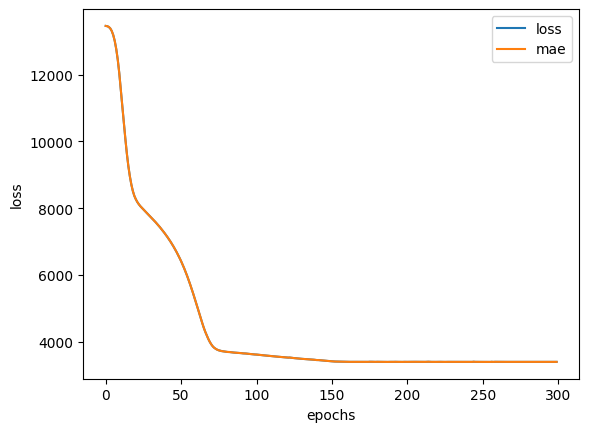

In [166]:
pd.DataFrame(history.history).plot()
plt.ylabel('loss')
plt.xlabel('epochs')